In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import pyvista as pv
from mat4py import loadmat
import re
from itertools import chain
import seaborn as sns
import ollama
from tqdm import tqdm
from collections import defaultdict
import os
from dotenv import load_dotenv
load_dotenv(); 
usda_api_key = os.environ["MY_USDA_API_KEY"]
from utils import conversions, densities

from usda_fdc import FdcClient


def extract_ingredients(s):
    return [ingredient.lower() for ingredient in re.findall(r'"(.*?)"', s)]


## 1. Units of measurement - Part 1

In `3_llm_parse_burger_ingredients.py` I used an llm to bring the ingredient data into a slightly more usable format of "quantity, unit of measurement, name". However, the LLM outputs are still messy and need a lot of work.

Clean up the LLM outputs, separate any entries that contain more than one ingredient, make everything singular so as to unify them, remove LLM comments, remove some descriptors, etc.

In [5]:
burgers = pd.read_csv('data/burgers.csv')

# Process the ingredients data from the LLM
with open('data/burger_ingredients.pkl', 'rb') as f:
    ingr_data = pickle.load(f)
def make_lowercase(nested_list):
    result = []
    for sublist in nested_list:
        new_sublist = []
        for item in sublist:
            new_sublist.append(item.lower())
        result.append(new_sublist)
    return result
ingr_data = make_lowercase(ingr_data)

burgers['llm_outputs'] = ingr_data

# Check if the ingredients list for any recipe has to be expanded (say, separate 'salt and pepper' into two ingredients)
def split_strings(nested_list):
    result = []
    pattern = r'"(.*?)"'  # Matches content inside double quotes

    for sublist in nested_list:
        new_sublist = []
        for item in sublist:
            # Step 1: Split on newline
            parts = item.split('\n')

            # remove empty strings
            new_parts = []
            for part in parts:
                if part.strip():
                    new_parts.append(part)
            
            for part in new_parts:
                part = part.strip()

                 # Step 2: If exactly 6 parts separated by commas, split and add
                if len(part.split(',')) == 6:
                    new_sublist.append(','.join([s.strip() for s in part.split(',')[:3]]))
                    new_sublist.append(','.join([s.strip() for s in part.split(',')[4:]]))
                    continue
                
                # Step 3: Check for multiple quoted strings
                matches = re.findall(pattern, part)
                if len(matches) > 1:
                    for match in matches:
                        if len(match) >= 3:
                            new_sublist.append(match)
                    continue
                else:
                    if len(part) >= 2:
                        new_sublist.append(part)
               
            
        result.append(new_sublist)
    return result
ingr_data = split_strings(ingr_data)

# Remove descriptors in cases like: "Nan, -, pepper, ground"
def split_and_truncate_commas(nested_list):
    result = []

    for sublist in nested_list:
        new_sublist = []
        for item in sublist:
            parts = [p.strip() for p in item.split(',')][:3]
            new_parts = []
            for part in parts:
                new_parts.append(part.replace('"', ''))
            if len(new_parts) == 2:
                new_parts = [new_parts[0], '-', new_parts[1]]
            if len(new_parts) > 2:
                new_sublist.append(new_parts)
        result.append(new_sublist)

    return result

# Remove ingredients with less than 2 entries
ingr_data = split_and_truncate_commas(ingr_data)


In [162]:
ingr_qnty = [ingr[0] for ingr_list in ingr_data for ingr in ingr_list]
ingr_unit = [ingr[1] for ingr_list in ingr_data for ingr in ingr_list]
ingr_name = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]

print('Number of unique names: ', len(np.unique(ingr_name)))
print('Number of unique units: ', len(np.unique(ingr_unit)))

Number of unique names:  3683
Number of unique units:  189


Simplify and unify the units

In [163]:
# Make units singular
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        ingr = ingr_data[i][j]
        if ingr[1] and ingr[1][-1] == 's':
            ingr_data[i][j] = [ingr[0], ingr[1][:-1], ingr[2]]
        if ingr[1] and ingr[1][-3:] == '(s)':
            ingr_data[i][j] = [ingr[0], ingr[1][:-3], ingr[2]]
ingr_unit = [ingr[1] for ingr_list in ingr_data for ingr in ingr_list]
print('Number of unique units: ', len(np.unique(ingr_unit)))

Number of unique units:  171


Unify different spellings

In [164]:
replace_list = {
    'assume nan': 'nan',
    'g': 'gr',
    'count': '-',
    'ct': '-',
    'fl_oz': 'fl oz',
    'fluid ounce': 'fl oz',
    'gram': 'gr',
    'gm': 'gr',
    'oz (assuming average weight of an apple is 1 lb or 16 oz)': 'oz',
    'pc': '-',
    'piece': '-',
    'tablespoon': 'tbsp',
    'tbl': 'tbsp',
    'teaspoon': 'tsp',
    'the unit is tablespoon': 'tbsp',
    'each': '-',
    'ea': '-',
    'nan': 'na',
    'none': 'na',
    'n': '-',
    'shake': 'tsp',
    'egg (note: in this case': 'egg',
    'medium': '-',
    'med': '-',
    'liter': 'l',
    'unitles': '-',
    'tab': 'tbsp',
    'leave': 'leaf',
    'unit': '-',
    'stem': 'stalk',
    'sprig': 'bunch',
    '': '-',
    '_': '-',
    'unit not specified': 'na',
    'lb/oz': 'na',
    'inch': 'in',
    'inches': 'in',
    'inche': 'in',
    'spray': 'na',
}

for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        ingr = ingr_data[i][j]
        if ingr[1] in replace_list.keys():
            ingr_data[i][j] = [ingr[0], replace_list[ingr[1]], ingr[2]]

ingr_unit = [ingr[1] for ingr_list in ingr_data for ingr in ingr_list]
print('Number of unique units: ', len(np.unique(ingr_unit)))

Number of unique units:  135


Remove all the recipes with units that occur only once

In [165]:
burgers['qnty_list'] = [[ingr[0] for ingr in ingr_list] for ingr_list in ingr_data]
burgers['unit_list'] = [[ingr[1] for ingr in ingr_list] for ingr_list in ingr_data]
burgers['name_list'] = [[ingr[2] for ingr in ingr_list] for ingr_list in ingr_data]

unique_unit, unit_counts = np.unique(ingr_unit, return_counts=True)
unit_counts = {str(unit):int(count) for unit, count in zip(unique_unit, unit_counts)} # How many times a given unit was seen anywhere

mask = np.ones(len(burgers))
for i in range(len(burgers)):
    unit_list = burgers.iloc[i]['unit_list']
    for unit in unit_list:
        if unit_counts[unit] < 3:
            mask[i] = 0
            continue
burgers = burgers[mask == 1].reset_index(drop=True)
ingr_data = [item for item, m in zip(ingr_data, mask) if m == 1]

ingr_qnty = [ingr[0] for ingr_list in ingr_data for ingr in ingr_list]
ingr_unit = [ingr[1] for ingr_list in ingr_data for ingr in ingr_list]
ingr_name = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]

print('Number of unique names: ', len(np.unique(ingr_name)))
print('Number of unique units: ', len(np.unique(ingr_unit)))

Number of unique names:  3573
Number of unique units:  43


Remove recipes with non-standard units such as 'can' or 'package'

In [166]:
nonstandard_units = [
    'can',
    'package',
    'envelope',
    'jar'
]
mask = np.ones(len(burgers))
for i in range(len(burgers)):
    unit_list = burgers.iloc[i]['unit_list']
    for unit in unit_list:
        if unit in nonstandard_units:
            mask[i] = 0
            continue
burgers = burgers[mask == 1].reset_index(drop=True)
ingr_data = [item for item, m in zip(ingr_data, mask) if m == 1]

ingr_qnty = [ingr[0] for ingr_list in ingr_data for ingr in ingr_list]
ingr_unit = [ingr[1] for ingr_list in ingr_data for ingr in ingr_list]
ingr_name = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]

print('Number of unique names: ', len(np.unique(ingr_name)))
print('Number of unique units: ', len(np.unique(ingr_unit)))

Number of unique names:  3549
Number of unique units:  39


A lot of recipes have "egg" in the place of unit instead of name. Correct this.

In [167]:
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        ingr = ingr_data[i][j]
        if ingr[1] == 'egg' or ingr[1] == 'egg white' or ingr[1] == 'yolk':
            ingr_data[i][j] = [ingr[0], '-', 'egg']
        
        if ingr[1] == 'avocado':
            ingr_data[i][j] = [ingr[0], '-', 'avocado']

In [168]:
# Resolve numerical units, and switch unit and quantity if need be
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        ingr = ingr_data[i][j]
        try:
            eval_a = eval(ingr[1])
            if isinstance(eval_a, (int, float)): # the 'unit' is a number
                try:
                    eval_b = eval(ingr[0])
                    if isinstance(eval_b, (int, float)): # the 'quantity' is also a number
                        ingr_data[i][j] = [eval_a*eval_b, '-', ingr[2]]
                except: # the unit is a number, but quantity is a string
                    ingr_data[i][j] = [ingr[1], ingr[0], ingr[2]]
        except: # Neither the unit nor the quantity are numbers
            parts = ingr[1].split()
            if len(parts) > 1:
                try:
                    qnty = eval(parts[0])
                    unit = eval(ingr[0])
                    # in this case the unit is something like '15 oz' and quantity is a number
                    if isinstance(qnty, (int, float)) and isinstance(unit, (int, float)):
                        ingr_data[i][j] = [unit*qnty, parts[1], ingr[2]]
                except:
                    continue


burgers['qnty_list'] = [[ingr[0] for ingr in ingr_list] for ingr_list in ingr_data]
burgers['unit_list'] = [[ingr[1] for ingr in ingr_list] for ingr_list in ingr_data]
burgers['name_list'] = [[ingr[2] for ingr in ingr_list] for ingr_list in ingr_data]

In [169]:
valid_units = [
    'gr',
    'kg',
    'lb',
    '-',
    'oz',
    'tbsp',
    'tsp',
    'fl oz',
    'cup',
    'na',
    'dash',
    'slice',
    'ml',
    'gal',
    'qt',
    'clove',
    'stalk',
    'head',
    'loaf',
    'pt',
    'pinch',
    'cube',
    'leaf',
    'l',
    'drop',
    'in',
    'ring',
    'cm',
    'bunch',
    'sheet',
]

for i in range(len(burgers)):
    qnty_list = burgers.iloc[i]['qnty_list']
    unit_list = burgers.iloc[i]['unit_list']
    name_list = burgers.iloc[i]['name_list']

    for j in range(len(unit_list)):
        unit = unit_list[j]
        if not unit in valid_units:
            print(qnty_list)
            print(unit_list, unit)
            print(name_list)
            # print(burgers.iloc[i]['llm_outputs'])
            print(burgers.iloc[i]['ingredients_raw'])
            # print(burgers.iloc[i]['Name'])
            print('-'*100)
            continue

Look at the cases where the quantity is given but not the unit.

In [170]:
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        ingr = ingr_data[i][j]

        qnty = ingr[0]
        unit = ingr[1]
        name = ingr[2]
        if qnty != 'nan' and unit == 'na':
            ingr_data[i][j] = ['nan', 'na', name] # If the units of measurement is not given, treat it as if the quantity is not given
            continue
burgers['qnty_list'] = [[ingr[0] for ingr in ingr_list] for ingr_list in ingr_data]
burgers['unit_list'] = [[ingr[1] for ingr in ingr_list] for ingr_list in ingr_data]
burgers['name_list'] = [[ingr[2] for ingr in ingr_list] for ingr_list in ingr_data]
ingr_qnty = [ingr[0] for ingr_list in ingr_data for ingr in ingr_list]
ingr_unit = [ingr[1] for ingr_list in ingr_data for ingr in ingr_list]
ingr_name = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]

print('Number of recipes: ', len(burgers))
print('Number of unique names: ', len(np.unique(ingr_name)))
print('Number of unique units: ', len(np.unique(ingr_unit)))

Number of recipes:  3725
Number of unique names:  3535
Number of unique units:  30


In [171]:
with open('data/burgers_step2.pkl', 'wb') as f:
    pickle.dump([ingr_data, burgers], f)

Now, all the ingredients are measured in 1 of 30 units.

## 2. Ingredient names

At this point we are still not done cleaning up units of measurement. However, we need to clean up ingredient names a bit before we proceed. This is for 2+ reasons. 1) once we know exactly which ingredients we will be working on, we can remove a lot of ingredients that are not commonly used and this will simplify things for us. 2) This step will unify a lot of products into one (for example, tomato sauce, sliced tomatoes, tomatoes, crushed tomatoes etc will become one product). Once we have this, we will be able to unify the units of measurement used for this product.

At this point you need to run `llm_simplify_names.py`

In [ ]:
# # This needs to be executed with ollama server running. (Probably best to do it on the cluster)
# %run llm_simplify_names.py

In [276]:
with open('data/burgers_step2.pkl', 'rb') as f:
    ingr_data, burgers = pickle.load(f)

ingr_names = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]
unique_names, name_counts = np.unique(ingr_names, return_counts=True)
print('Unique ingredients: ', len(unique_names))

Unique ingredients:  3535


The script `llm_simplify_names.py` used an LLM to remove all descriptors from product names (all processing steps such as "crushed" or "boiled", all marketing names, etc). However, the outputs of the LLM are not very consistent, so we need to clean up a little.

Also, make everything singular so as not to have multiple entries for the same product.

In [277]:
with open('data/simplified_names.pkl', 'rb') as f:
    names = pickle.load(f)

# Remove LLM comments (anything after a parantheses starts)
# Also the LLM puts things like "Lemon juice" -> Lemon
prefix_triggers = ['->', '→', 'becomes', 'simplified name:', '=>', ":", '[becomes]', '->', 'simplifies to', 'ingredient is',
                   'boils down to', 'is simplified to', ' = ', ' is ', ' become ', ]
cut_triggers = ['\n', '(', ',', ' or ', 'in this context', ' i ', ' but ', 'however', ' so ', '/', '[']

exceptions = {
    'drippings and further simplified': 'dripping',
    'beet cooking water simplifies to': 'water',
    'nan, whole wheat buns': 'bun',
    'peanut butter is peanuts': 'peanut butter',
    'pimentos stuffed olives simplifies to "olives"': 'olive',
    'buns with sesame seeds': 'bun',
    'taco seasoning mix contains multiple ingredients': 'seasoning mix',
    'drippings and further simplified as we are asked to only give the name of the ingredient': 'dripping',
    'lime juice contains the word juice': 'lime',
}

for i in range(len(names)):
    for j in range(len(names[i])):
        name = names[i][j].lower()

        # Manually fix some of the other problems
        for trigger in exceptions.keys():
            if name.find(trigger) >= 0:
                name = exceptions[trigger]


        # Remove everything starting from newline or '('
        for trigger in cut_triggers:
            idx = name.find(trigger)
            if idx > 0:
                name = name[:idx]

        # Keep everything *after* the first matching prefix trigger
        for trigger in prefix_triggers:
            idx = name.find(trigger)
            if idx > 0:
                name = name[idx + len(trigger):]
        
        name = name.replace('"', '')
        name = name.replace("'", '')
        name = name.replace('*', '')
        name = name.replace(':', '')
        name = name.replace('\\', '')
        name = name.replace('.', ' ')

        # Make everything singular
        # leaves was the only plural that changed from -f to -ves
        name = name.replace('leaves', 'leaf')
        name = name.replace('chilies', 'chili')
        name = name.replace('chilie', 'chili')
        name = name.replace('chiles', 'chili')
        name = name.replace('chile', 'chili')
        if name[-3:] == 'ies':
            name = name.replace('ies', 'y')
        if name[-3:] == 'oes':
            name = name.replace('oes', 'o')
        name = name.strip()
        if name[-1:] == 's' and not name in ['guinness', 'lemongrass', 'mustard cress', 'swiss', 'watercress', 'asparagus', \
                                             'au jus', 'aminos', 'coconut aminos', 'greens', 'hummus', 'liquid aminos', \
                                                'molasses', 'couscous']:
            name = name[:-1]
        

        names[i][j] = name.strip()



name_vec = [name for ingr_list in names for name in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)

In [278]:
print(len(unique_names))
for name in unique_names:
    print(name)

1133

21 seasoning salute
accent seasoning
achiote
adobo
adobo sauce
adobo seasoning
adzuki bean
agave
ahi tuna
aioli
ale
alfalfa sprout
alfredo
alfredo sauce
allspice
almond
almond butter
almond flour
almond meal
aluminum
aluminum foil
amaranth
aminos
anasazi bean
ancho chili
ancho powder
anchovy
andouille
angostura bitter
apple
apple cider vinegar
apple juice
apple pie spice
applesauce
apricot
apricot preserve
arrowroot
artichoke
artichoke heart
arugula
asafoetida
asiago
asparagus
au jus
avocado
avocado oil
bacon
bacon bit
bacon dripping
bacon grease
badia
bagel
baguette
baking mix
baking powder
baking soda
balsamic
balsamic vinaigrette
balsamic vinegar
bamboo shoot
banana
banana pepper
barbecue
barbecue sauce
barbecue sauce concentrate
barbecue seasoning
barbeque sauce
barley
basil
basil pesto
batter
bay leaf
bbq sauce
bean
bean liquid
bean sprout
beau monde
beau monte
beef
beef bouillon
beef bouillon cube
beef broth
beef burger
beef cube
beef gravy
beef powder
beefaroni
beer
beet
b

This next step is bulky and requires a lot of manual work. Manually go through the list of unique ingredients and make modifications to unify similar products.

Among others, this step does the following:
- Remove marketing terms and brand names 
- Simplify all proprietary seasoning mixes and less commonly used seasonings into simply "seasoning" (This excludes prominent varieties such as taco seasoning, steak seasoning etc.)
- Combine multiple ways of writing the same product (For example, some entries use "adobo" and some "adobo sauce". combine these. Example 2: "artichoke" and "artichoke hearts".)
- Combine products that are very similar to each other such as "baking powder", "baking soda" and "baking mix".
- All types of bread become one of "bread", "roll", or "bun" depending on which one they mention.
- Fix misspellings
- Combine all wines, all beers, etc
- All egg parts become "egg" (e.g. egg whites, egg yolk, egg substitute)
- All sodas are combined into one (coke, dr pepper, etc)
- All chips are combined into one
- All beef products are combined into one (beef, steak, ground beef, beef chuck, etc) (this does not include "burger" as they are patties)
- Similarly chicken and pork

In [279]:
# Unify some items that are either very close to each other, or different names of the same product
manual_corrections = {
    '21 seasoning salute': 'other seasoning',
    'accent seasoning': 'other seasoning',
    'adobo': 'adobo sauce',
    'alfredo': 'alfredo sauce',
    'almond flour': 'almond',
    'almond meal': 'almond',
    'aluminum': 'aluminum foil',
    'artichoke heart': 'artichoke',
    'asafoetida': 'hing',
    'bacon bit': 'bacon',
    'bacon dripping': 'bacon grease',
    'baking mix': 'baking powder',
    'baking soda': 'baking powder',
    'balsamic vinaigrette': 'balsamic vinegar',
    'balsamic': 'balsamic vinegar',
    'barbecue': 'barbecue sauce',
    'barbecue sauce concentrate': 'barbecue sauce',
    'barbeque sauce': 'barbecue sauce',
    'bbq sauce': 'barbecue sauce',
    'basil pesto': 'pesto',
    'batter': 'dough',
    'beau monte': 'beau monde',
    'beef bouillon cube': 'beef bouillon',
    'beef burger': 'patty',
    'beef cube': 'bouillon',
    'beef powder': 'beef bouillon',
    'beetroot': 'beet',
    'black beans burger': 'black bean burger',
    'black mustard seed': 'black mustard',
    'black pepper': 'pepper', # pepper will refer to black pepper
    'blackening season': 'blackening seasoning',
    'bleu cheese dressing': 'blue cheese dressing',
    'bouillon cube': 'bouillon',
    'bouillon granule': 'bouillon',
    'boursin': 'boursin cheese',
    'bragg aminos': 'aminos',
    'braggs liquid aminos': 'aminos',
    'bread crumb': 'breadcrumb',
    'bread dough': 'dough',
    'bread roll': 'roll',
    'breading': 'breadcrumb',
    'breadstick': 'bread',
    'brioche': 'bun',
    'brioche bun': 'bun',
    'broccolini': 'broccoli',
    'brown gravy': 'gravy',
    'budweiser': 'beer',
    'buffalo meat': 'buffalo',
    'buffallo meat': 'buffalo',
    'buffalomeat': 'buffalo',
    'buter': 'butter',
    'bulgar': 'bulgur',
    'bulls eye barbecue sauce': 'barbecue sauce',
    'butter bean': 'lima bean',
    'butterbean': 'lima bean',
    'cabernet sauvignon': 'wine',
    'canadian bacon': 'bacon',
    'canola': 'canola oil',
    'capsicum': 'bell pepper',
    'catsup': 'ketchup',
    'cayenne': 'cayenne pepper',
    'ceasar dressing': 'caesar dressing',
    'challah': 'bun',
    'challah bun': 'bun',
    'cheddar': 'cheddar cheese',
    'cheese': 'other cheese',
    'chicken burger': 'patty',
    'chicken bouillon granule': 'chicken bouillon',
    'chicken breast': 'chicken',
    'chicken gumbo soup': 'chicken soup',
    'chicken stock': 'chicken broth',
    'chicken stock powder': 'chicken bouillon',
    'chicken thigh': 'chicken',
    'chickpea flour': 'chickpea',
    'chili pepper': 'chili',
    'chili pepper flake': 'chili flake',
    'chili powder': 'chili flake',
    'chili paste': 'chili sauce',
    'chili seasoning': 'other seasoning',
    'chili-garlic': 'chili garlic sauce',
    'chili-garlic sauce': 'chili garlic sauce',
    'chili_pepper': 'chili',
    'chilli': 'chili',
    'chipotle': 'chipotle chili',
    'chipotle in adobo': 'chipotle chili',
    'chipotle pepper': 'chipotle chili',
    'chipotle pepper sauce': 'chipotle sauce',
    'cholula': 'hot sauce',
    'chow mein noodle': 'noodle',
    'chiabatta': 'bread',
    'chiabatta bread': 'bread',
    'chibatta': 'bread',
    'cider': 'cider vinegar',
    'coating': 'coating mix',
    'coconut aminos': 'aminos',
    'cognac': 'brandy',
    'coke': 'soda',
    'cola': 'soda',
    'coleslaw mix': 'coleslaw',
    'cookie mix': 'dough',
    'coriander': 'coriander seed',
    'cornbreadcrumb': 'breadcrumb',
    'corn flake': 'cornflake',
    'cornmeal': 'cornflour',
    'cornmeal mix': 'cornflour',
    'cornstarch': 'cornflour',
    'courgette': 'zucchini',
    'crab boil': 'crab',
    'crabmeat': 'crab',
    'cracked pepper': 'pepper',
    'cracker crumb': 'cracker',
    'cranberrie': 'cranberry',
    'cream of chicken': 'chicken soup',
    'cream of mushroom soup': 'mushroom soup',
    'cream of mushroom': 'mushroom soup',
    'crema': 'cream',
    'creme fraiche': 'cream',
    'crescent': 'roll',
    'crescent roll': 'roll',
    'crisco': 'shortening',
    'croutoon': 'breadcrumb',
    'crumb': 'breadcrumb',
    'crust': 'bread',
    'curry paste': 'curry',
    'deer meat': 'deer',
    'dinner roll': 'roll',
    'dorito': 'chip',
    'dr  pepper': 'soda',
    'dried seasoning': 'other seasoning',
    'duck breast': 'duck',
    'egg substitute': 'egg',
    'egg white': 'egg',
    'egg yolk': 'egg',
    'eggwhite': 'egg',
    'elbow macaroni': 'pasta',
    'essence': 'creole seasoning',
    'essence seasoning': 'creole seasoning',
    'ezekiel bread': 'bread',
    'fajita seasoning mix': 'fajita seasoning',
    'fennel': 'fennel seed',
    'feta cheese': 'feta',
    'fiber one': 'cereal',
    'five-spice': 'other seasoning',
    'flax': 'flax seed',
    'flour  so': 'flour',
    'focaccia': 'bread',
    'foil': 'aluminum foil',
    'fontinella': 'fontina',
    'franks hot sauce': 'hot sauce',
    'franks red hot sauce': 'hot sauce',
    'frie': 'fry',
    'frisee': 'endive',
    'frito': 'chip',
    'garbanzo': 'garbanzo bean',
    'garlic and herb': 'garlic seasoning',
    'garlic and herb seasoning': 'garlic seasoning',
    'garlic and herb seasoning mix': 'garlic seasoning',
    'garlic herb': 'garlic seasoning',
    'garlic herb mix': 'garlic seasoning',
    'garlic salt': 'garlic seasoning',
    'gherkin': 'pickle',
    'grease': 'fat',
    'greek yogurt': 'yogurt',
    'green chili': 'chili',
    'green chili pepper': 'chili',
    'green curry': 'curry',
    'green herb powder': 'chili flake',
    'green pepper': 'chili',
    'grill': 'grill seasoning',
    'grill creations seasoning': 'grill seasoning',
    'ground beef': 'beef',
    'ground chuck': 'beef',
    'guacamoleaioli': 'guacamole',
    'guinness': 'beer',
    'habanero pepper': 'habanero',
    'ham': 'pork',
    'hamburger bun': 'bun',
    'hamburger': 'patty',
    'heavy cream': 'cream',
    'heinz 57': 'steak sauce',
    'heinz 57 sauce': 'steak sauce',
    'heinz relish': 'relish',
    'heinz sauce': 'steak sauce',
    'helper mix becomes mix': 'helper mix',
    'herbe': 'greens',
    'herb': 'greens',
    'herbes de provence': 'greens',
    'hickory chip': 'chip',
    'hidden valley original ranch': 'ranch sauce',
    'honey garlic': 'honey garlic sauce',
    'hot pepper sauce': 'hot sauce',
    'hot radish': 'radish',
    'israeli couscous': 'couscous',
    'jalopeno pepper': 'jalopeno',
    'jalopeno roll': 'roll',
    'jerk spice': 'jerk seasoning',
    'kaiser': 'roll',
    'kaiser roll': 'roll',
    'kalamata': 'olive',
    'kalamata olive': 'olive',
    'kashi': 'kasha',
    'kidney': 'kidney bean',
    'kidney fat': 'fat',
    'kitchen bouquet': 'other seasoning',
    'knorr': 'bouillon',
    'korma paste': 'curry',
    'lager': 'beer',
    'lard': 'fat',
    'lavash': 'tortilla',
    'lawry': 'salt',
    'lawrys salt': 'salt',
    'lawry seasoned salt': 'salt',
    'lemon  so': 'lemon',
    'lemon juice': 'lemon',
    'lettuces & spring green': 'lettuce',
    'limon': 'lemon',
    'lipton': 'soup mix',
    'lipton': 'soup mix',
    'liquid aminos': 'aminos',
    'macaroni': 'pasta',
    'maple sauce': 'maple syrup',
    'margarine': 'butter',
    'masa': 'dough',
    'masa harina': 'dough',
    'mayo': 'mayonnaise',
    'mccormick': 'other seasoning',
    'mccormick seasoning': 'other seasoning',
    'meat': 'beef',
    'meatball': 'patty',
    'mesquite': 'other seasoning',
    'mesquite seasoning': 'other seasoning',
    'mesquite wood chip': 'other seasoning',
    'mince': 'beef',
    'minced': 'beef',
    'mincemeat': 'beef',
    'mint leaf': 'mint',
    'miracle whip': 'dressing',
    'mix': 'other seasoning',
    'mixed spice': 'other seasoning',
    'mixed herb': 'other seasoning',
    'mixture': 'other seasoning',
    'monterey jack cheese': 'monterey jack',
    'monterey jack pepper': 'monterey jack',
    'montreal chicken seasoning': 'other seasoning',
    'montreal sauce': 'sauce',
    'montreal seasoning': 'other seasoning',
    'montreal spice': 'other seasoning',
    'montreal steak seasoning': 'steak seasoning',
    'montreal steak seasoning': 'steak seasoning',
    'morningstar farm': 'patty',
    'morningstar farms griller': 'patty',
    'morningstar farms grillers original': 'patty',
    'morton nature season': 'seasoning',
    'mr  yoshida': 'sauce',
    'mrs  dash': 'other seasoning',
    'naan': 'bread',
    'nuoc mam': 'fish sauce',
    'nuoc nam': 'fish sauce',
    'nuoc_cham': 'fish sauce',
    'nutritional yeast': 'yeast',
    'oat bran': 'oat',
    'oatmeal': 'oat',
    'old bay': 'other seasoning',
    'olive oil spray': 'olive oil',
    'onion mix': 'other seasoning',
    'onion mushroom mix': 'other seasoning',
    'orange juice': 'orange',
    'orange juice concentrate': 'orange',
    'pam': 'oil',
    'pam^{®} spray': 'oil',
    'panko': 'breadcrumb',
    'parkay butter flavored spray': 'oil',
    'paste': 'sauce',
    'pattie': 'patty',
    'burger': 'patty',
    'peache': 'peach',
    'peameal': 'bacon',
    'pepper flake': 'chili flake',
    'pepper mix': 'other seasoning',
    'pepper sauce': 'hot sauce',
    'peppercorn': 'pepper',
    'pepperoncini': 'chili',
    'peppersauce': 'hot sauce',
    'pickapeppa sauce': 'ketchup',
    'pickled ginger': 'ginger',
    'pickled onion': 'onion',
    'pickled pepper': 'chili',
    'picklejuice': 'pickle juice',
    'pimiento': 'pimento',
    'pink peppercorsn': 'pepper',
    'pita': 'bread',
    'pita bread': 'bread',
    'pita pocket': 'bread',
    'port': 'wine',
    'port wine': 'wine',
    'portabella mushroom': 'portobello',
    'portabella': 'portobello',
    'portabello': 'portobello',
    'portobello mushroom': 'portobello',
    'potato chip': 'chip',
    'potato flake': 'chip',
    'potatoe': 'potato',
    'poultry seasoning': 'chicken seasoning',
    'pretzel': 'bun',
    'pretzel bun': 'bun',
    'prudhomme meat magic': 'other seasoning',
    'psyllium husk powder': 'psyllium',
    'pumpernickel': 'bread',
    'pumpernickel bread': 'bread',
    'radishe': 'radish',
    'ramen noodle': 'noodle',
    'ranch dressing': 'ranch sauce',
    'ranch': 'ranch sauce',
    'ranch dressing mix': 'ranch sauce',
    'ranch mix': 'ranch sauce',
    'ranch salad dressing': 'ranch sauce',
    'red chili': 'chili',
    'red chili pepper': 'chili',
    'red pepper': 'chili',
    'red pepper flake': 'chili flake',
    'red sauce': 'hot sauce',
    'red wine': 'wine',
    'red kidney bean': 'kidney bean',
    'rib eye': 'beef',
    'rice flour': 'rice',
    'rice wine': 'wine',
    'rice wine vinegar': 'rice vinegar',
    'roll mix': 'dough',
    'rye bread': 'rye',
    'safflower': 'safflower oil',
    'salad dressing': 'dressing',
    'salad green': 'greens',
    'salad leaf': 'greens',
    'salsa and queso': 'salsa',
    'salsa verde': 'salsa',
    'salt and pepper': 'salt',
    'salt-free seasoning': 'other seasoning',
    'sambal oelek': 'hot sauce',
    'sandwich bun': 'bun',
    'sauvignon blanc': 'wine',
    'sazon': 'other seasoning',
    'sazon goya': 'other seasoning',
    'scallion': 'green onion',
    'schnitzel': 'chicken',
    'sea salt': 'salt',
    'seasoned salt': 'other seasoning',
    'seasoning mix': 'other seasoning',
    'seasoning salt': 'other seasoning',
    'serrano chili': 'serrano',
    'serrano chilli': 'serrano',
    'serrano pepper': 'serrano',
    'seasoning': 'other seasoning',
    'sesame': 'sesame seed',
    'sesame bread': 'bread',
    'sesame bun': 'bun',
    'sesame roll': 'roll',
    'seven spice': 'other seasoning',
    'sherry': 'sherry vinegar',
    'shitake': 'shiitake',
    'simplified as lime': 'lime',
    'simply ritz': 'ritz',
    'siracha': 'hot sauce',
    'sirloin': 'beef',
    'skim milk': 'milk',
    'sloppy joe mix': 'other seasoning',
    'smoky applewood seasoning mix': 'other seasoning',
    'soul seasoning': 'other seasoning',
    'sourdough': 'bread',
    'sourdough bread': 'bread',
    'sourdough bun': 'bun',
    'soy': 'soybean',
    'soya': 'soy sauce',
    'spaghetti': 'pasta',
    'spam': 'beef',
    'spearmint': 'mint',
    'spice': 'other seasoning',
    'spice mix': 'other seasoning',
    'spice mixture': 'other seasoning',
    'spray': 'oil',
    'spring onion': 'green onion',
    'squash': 'pumpkin',
    'sriracha': 'hot sauce',
    'sriracha sauce': 'hot sauce',
    'steak': 'beef',
    'steak spice': 'steak seasoning',
    'stock': 'broth',
    'stuffing mix': 'stuffing',
    'sugar substitute': 'sugar',
    'sunflower': 'sunflower oil',
    'sweet chili': 'chili',
    'sweet chili sauce': 'hot sauce',
    'swiss': 'swiss cheese',
    'tabasco': 'hot sauce',
    'tabasco pepper sauce': 'hot sauce',
    'tabasco sauce': 'hot sauce',
    'taco seasoning mix': 'taco seasoning',
    'tamari': 'soy sauce',
    'tarragon and parsley': 'tarragon',
    'teriyaki': 'teriyaki sauce',
    'teriyaki marinade': 'teriyaki sauce',
    'texas pete': 'hot sauce',
    'texas toast': 'toast',
    'textured protein': 'protein',
    'textured vegetable protein': 'protein',
    'thai basil': 'basil',
    'thai chili': 'chili',
    'thai chili sauce': 'hot sauce',
    'thai curry paste': 'curry',
    'thai fish sauce': 'fish sauce',
    'thai red curry': 'curry',
    'thai seasoning': 'other seasoning',
    'thai sweet chili': 'chili',
    'tikka masala curry': 'curry',
    'tomato barbecue sauce': 'barbecue sauce',
    'tomato basil': 'tomato',
    'tomato juice': 'tomato',
    'tomato mayonnaise': 'mayonnaise',
    'tomato pesto': 'past',
    'tomato sauce': 'tomato',
    'tomatoe': 'tomato',
    'tomatoes and green chili': 'tomato',
    'tony chachere': 'other seasoning',
    'tony chacheres seasoning': 'other seasoning',
    'tortilla chip': 'chip',
    'tortilla corn': 'tortilla',
    'tortilla corn flour': 'cornflour',
    'tortilla corn masa': 'cornflour',
    'tortilla corn masa harina': 'cornflour',
    'tortilla corn maseca instant mexican maize flour': 'cornflour',
    'tortilla flour': 'flour',
    'tot': 'tater tot',
    'veal': 'beef',
    'vegetable': 'greens',
    'vegetable oil': 'oil',
    'veggie burger': 'patty',
    'velveeta': 'other cheese',
    'vermouth': 'wine',
    'vital wheat gluten': 'gluten',
    'wheat bran': 'bran',
    'wheat gluten': 'gluten',
    'white pepper': 'pepper',
    'white wine': 'wine',
    'whole wheat': 'bread',
    'worcestershire': 'worcestershire sauce',
    'yeast extract': 'yeast',
    'yeast flake': 'yeast',
    'yoghurt': 'yogurt',
    'yolk': 'egg',
}

for i in range(len(names)):
    for j in range(len(names[i])):
        name = names[i][j].lower()
        if name in manual_corrections.keys():
            name = manual_corrections[name]
        
        names[i][j] = name


name_vec = [name for ingr_list in names for name in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)
sort_idx = np.argsort(name_counts)
unique_names, name_counts = unique_names[sort_idx], name_counts[sort_idx]

print(len(unique_names))
for i in range(len(unique_names)):
    print(name_counts[i], unique_names[i])

709
1 kaffir lime leaf
1 ciabatta bread
1 cibatta
1 phyllo cup
1 pesto mix
1 clover sprout
1 pernod
1 pepper jelly
1 pepita
1 pearl barley
1 consommé
1 pastry
1 pastrami
1 corn relish
1 past
1 cornbread
1 parmigiano-reggiano cheese
1 papalo
1 nakano vinegar
1 navy bean
1 neufchatel
1 not explicitly given  the word package refers to a container
1 crumbled
1 onion dip
1 piquillo pepper
1 onion ring
1 orange zest
1 ostrich
1 oyster
1 craisin
1 oz
1 package
1 orange peel
1 mustard cress
1 pizza sauce
1 plum
1 cayenne sauce
1 ras el hanout
1 ranch seasoning
1 ragu
1 chanterelle
1 chavrie
1 radish sprout
1 cheddar jack
1 cheese curd
1 cheese salsa
1 cheeseburger macaroni
1 cheesy potatoe
1 cheesy taco mix
1 cheez whiz
1 cheez-it
1 cherry wood salt
1 chervil
1 chipotle ranch
1 polenta
1 chipotle mayonnaise
1 pomegranate seed
1 chimichurri
1 ponzu sauce
1 plantain
1 chili relish
1 portobella
1 jackfruit
1 prawn
1 pulp
1 pumpkin pie spice
1 chevre
1 porcini
1 raspberry chipotle
1 dill seed
1 mu

Remove all the recipes with ingredients that are used in <10 recipes

In [280]:
name_counts_dict = {name:count for name, count in zip(unique_names,name_counts)}
mask = np.ones(shape=len(names), dtype='int')

threshold = 10
for i in range(len(names)):
    for j in range(len(names[i])):
        if name_counts_dict[names[i][j]] < threshold:
            mask[i] = 0
            continue

burgers = burgers[mask.astype(bool)]
ingr_data = [item for item, m in zip(ingr_data, mask) if m == 1]
names = [item for item, m in zip(names, mask) if m == 1]

name_vec = [name for ingr_list in names for name in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)
print('# Recipes: ', len(burgers))
print('# Unique ingredients: ', len(unique_names))
print('Recipe to ingredient ratio: ', len(burgers)/len(unique_names))

# Recipes:  2832
# Unique ingredients:  248
Recipe to ingredient ratio:  11.419354838709678


In [281]:
print(len(unique_names))
for name in unique_names:
    print(name)

248
adobo sauce
alfalfa sprout
allspice
almond
aluminum foil
ancho chili
apple
apple cider vinegar
artichoke
arugula
avocado
bacon
baking powder
balsamic vinegar
barbecue sauce
barley
basil
bay leaf
bean
bean sprout
beef
beer
beet
bell pepper
bibb lettuce
biscuit
black bean
blue cheese
bouillon
bread
breadcrumb
brie
broccoli
broth
brown sugar
buffalo
bulgur
bun
butter
buttermilk
cabbage
cajun seasoning
cannellini
canola oil
caper
carrot
cashew
cayenne pepper
celery
celery seed
cheddar cheese
chestnut
chicken
chicken seasoning
chickpea
chili
chili flake
chili sauce
chip
chipotle chili
chive
chorizo
chutney
ciabatta
cider vinegar
cilantro
cinnamon
clove
coleslaw
condiment
coriander seed
corn
cornflake
cornflour
cottage cheese
couscous
crab
cracker
cranberry
cream
cream cheese
cremini
creole seasoning
cucumber
cumin
curry
curry powder
dill
dough
dressing
egg
eggplant
fennel seed
feta
fish sauce
flax seed
flour
fontina
garam masala
garlic
ginger
gluten
goat cheese
gorgonzola
gouda
green be

Modifications:
- Remove multiple varieties of the most vegetables and fruits (e.g., red kidney beans, pinto beans, etc become 'beans'. Romaine lettuce, bibb lettuce etc become 'lettuce'.).
- All vinegar types are combined into one.
- Combine all liquid oils into one.
- Combine all fish into one.
- Combine 'bread', 'ciabatta', 'muffin' (english muffin), 'biscuit', 'bun' and 'roll' into one.
- etc

In [282]:
replacements = {
    'cannellini': 'bean',
    'kidney bean': 'bean',
    'black bean': 'bean',
    'pinto bean': 'bean',
    'bibb lettuce': 'lettuce',
    'romaine': 'lettuce',
    'apple cider vinegar': 'vinegar',
    'red vinegar': 'vinegar',
    'sherry vinegar': 'vinegar',
    'white vinegar': 'vinegar',
    'rice vinegar': 'vinegar',
    'cider vinegar': 'vinegar',
    'red wine vinegar': 'vinegar',
    'balsamic vinegar': 'vinegar',
    'sunflower oil': 'oil',
    'peanut oil': 'oil',
    'sesame oil': 'oil',
    'canola oil': 'oil',
    'olive oil': 'oil',
    'pickle relish': 'relish',
    'tuna': 'fish',
    'salmon': 'fish',
    'bread': 'bun',
    'roll': 'bun',
    'ciabatta': 'bun',
    'muffin': 'bun',
    'biscuit': 'bun',
    'chili sauce': 'hot sauce',
}

for i in range(len(names)):
    for j in range(len(names[i])):
        name = names[i][j].lower()
        if name in replacements.keys():
            name = replacements[name]
        
        names[i][j] = name

name_vec = [name for ingr_list in names for name in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)
print('# Recipes: ', len(burgers))
print('# Unique ingredients: ', len(unique_names))
print('Recipe to ingredient ratio: ', len(burgers)/len(unique_names))

# Recipes:  2832
# Unique ingredients:  221
Recipe to ingredient ratio:  12.81447963800905


In [283]:
print(len(unique_names))
for name in unique_names:
    print(name)

221
adobo sauce
alfalfa sprout
allspice
almond
aluminum foil
ancho chili
apple
artichoke
arugula
avocado
bacon
baking powder
barbecue sauce
barley
basil
bay leaf
bean
bean sprout
beef
beer
beet
bell pepper
blue cheese
bouillon
breadcrumb
brie
broccoli
broth
brown sugar
buffalo
bulgur
bun
butter
buttermilk
cabbage
cajun seasoning
caper
carrot
cashew
cayenne pepper
celery
celery seed
cheddar cheese
chestnut
chicken
chicken seasoning
chickpea
chili
chili flake
chip
chipotle chili
chive
chorizo
chutney
cilantro
cinnamon
clove
coleslaw
condiment
coriander seed
corn
cornflake
cornflour
cottage cheese
couscous
crab
cracker
cranberry
cream
cream cheese
cremini
creole seasoning
cucumber
cumin
curry
curry powder
dill
dough
dressing
egg
eggplant
fennel seed
feta
fish
fish sauce
flax seed
flour
fontina
garam masala
garlic
ginger
gluten
goat cheese
gorgonzola
gouda
green bean
green onion
greens
gruyere
guacamole
havarti
hoisin sauce
honey
horseradish
hot sauce
hummus
italian seasoning
jalapeno
jerk

One more frequency filter: Remove all the recipes with ingredients that are used in <15 recipes

In [284]:
name_counts_dict = {name:count for name, count in zip(unique_names,name_counts)}
mask = np.ones(shape=len(names), dtype='int')

threshold = 15
for i in range(len(names)):
    for j in range(len(names[i])):
        if name_counts_dict[names[i][j]] < threshold:
            mask[i] = 0
            continue

burgers = burgers[mask.astype(bool)]
ingr_data = [item for item, m in zip(ingr_data, mask) if m == 1]
names = [item for item, m in zip(names, mask) if m == 1]

name_vec = [name for ingr_list in names for name in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)
print('# Recipes: ', len(burgers))
print('# Unique ingredients: ', len(unique_names))
print('Recipe to ingredient ratio: ', len(burgers)/len(unique_names))

# Recipes:  2218
# Unique ingredients:  147
Recipe to ingredient ratio:  15.08843537414966


In [285]:
for i in range(len(names)):
    for j in range(len(names[i])):
        name = names[i][j]
        qnty, unit, _ = ingr_data[i][j]

        ingr_data[i][j] = [qnty, unit, name]

In [286]:
with open('data/burgers_step3.pkl', 'wb') as f:
    pickle.dump([ingr_data, burgers], f)

## 3. USDA Food IDs

At this point, lets pair up our foods with USDA foods. This will enable us to use USDA's nutrition and size information later on.

In [8]:
with open('data/burgers_step3.pkl', 'rb') as f:
    ingr_data, burgers = pickle.load(f)
name_vec = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)

In [487]:
unique_names

array(['allspice', 'almond', 'apple', 'arugula', 'avocado', 'bacon',
       'barbecue sauce', 'basil', 'bean', 'beef', 'beer', 'beet',
       'blue cheese', 'breadcrumb', 'broth', 'brown sugar', 'buffalo',
       'bulgur', 'bun', 'butter', 'cabbage', 'cajun seasoning', 'carrot',
       'cayenne pepper', 'celery', 'cheddar cheese', 'chicken',
       'chicken seasoning', 'chickpea', 'chili', 'chili flake', 'chip',
       'chipotle chili', 'chive', 'cilantro', 'cinnamon',
       'coriander seed', 'corn', 'cornflour', 'cottage cheese', 'cracker',
       'cranberry', 'cream', 'cream cheese', 'cucumber', 'cumin', 'curry',
       'curry powder', 'dill', 'dough', 'dressing', 'egg', 'feta', 'fish',
       'flour', 'garlic', 'ginger', 'goat cheese', 'gouda', 'green onion',
       'greens', 'guacamole', 'hoisin sauce', 'honey', 'horseradish',
       'hot sauce', 'italian seasoning', 'jalapeno', 'ketchup', 'lamb',
       'lemon', 'lentil', 'lettuce', 'lime', 'liquid smoke', 'mango',
       'marjor

In [516]:
# Use the following cells to fill out this dict
from utils import usda_codes

In [488]:
client = FdcClient(usda_api_key)
results = client.search("bouillon")
for food in results.foods:
    print(f"{food.description} (FDC ID: {food.fdc_id})")

Soup, chicken broth or bouillon, dry (FDC ID: 171562)
Soup, beef broth or bouillon, powder, dry (FDC ID: 171560)
Soup, beef broth bouillon and consomme, canned, condensed (FDC ID: 171548)
Soup, beef broth or bouillon canned, ready-to-serve (FDC ID: 171538)
Soup, beef broth or bouillon, powder, prepared with water (FDC ID: 172922)
Soup, bouillon cubes and granules, low sodium, dry (FDC ID: 171613)
Soup, chicken broth or bouillon, dry, prepared with water (FDC ID: 172924)
Soup, beef broth, bouillon, consomme, prepared with equal volume water (FDC ID: 174557)
CHICKEN BOUILLON POWDER, CHICKEN BOUILLON (FDC ID: 2505414)
BEEF BOUILLON (FDC ID: 2080546)
BEEF BOUILLON (FDC ID: 1897809)
BOUILLON CUBES (FDC ID: 2100731)
BOUILLON CUBES (FDC ID: 490535)
BOUILLON CUBES (FDC ID: 2080466)
BOUILLON CUBES (FDC ID: 390688)
BOUILLON CUBES (FDC ID: 588392)
BOUILLON, CHICKEN (FDC ID: 2283971)
CHICKEN BOUILLON (FDC ID: 1897810)
GRANULATED BOUILLON (FDC ID: 2024206)
INSTANT BOUILLON (FDC ID: 2089056)
INSTANT

In [209]:
id = 2708489
food = client.get_food(id)

print(food.description)
print(food.food_category)
print(food.serving_size)
print(food.serving_size_unit)
print(food.food_portions)

nutrients = client.get_nutrients(id)
for nutrient in nutrients:
    print(f"{nutrient.name}: {nutrient.amount} {nutrient.unit_name}")

Oats, raw
None
None
None
[FoodPortion(id=303128, amount=0, gram_weight=10, portion_description='Quantity not specified', modifier='90000', measure_unit='undetermined'), FoodPortion(id=303127, amount=0, gram_weight=80, portion_description='1 cup', modifier='10205', measure_unit='undetermined')]
Protein: 13.2 g
Total lipid (fat): 6.52 g
Carbohydrate, by difference: 67.7 g
Energy: 379 kcal
Alcohol, ethyl: 0.0 g
Water: 10.8 g
Caffeine: 0.0 mg
Theobromine: 0.0 mg
Total Sugars: 0.99 g
Fiber, total dietary: 10.1 g
Calcium, Ca: 52.0 mg
Iron, Fe: 4.25 mg
Magnesium, Mg: 138 mg
Phosphorus, P: 410 mg
Potassium, K: 362 mg
Sodium, Na: 6.0 mg
Zinc, Zn: 3.64 mg
Copper, Cu: 0.391 mg
Selenium, Se: 28.9 µg
Retinol: 0.0 µg
Vitamin A, RAE: 0.0 µg
Carotene, beta: 0.0 µg
Carotene, alpha: 0.0 µg
Vitamin E (alpha-tocopherol): 0.42 mg
Vitamin D (D2 + D3): 0.0 µg
Cryptoxanthin, beta: 0.0 µg
Lycopene: 0.0 µg
Lutein + zeaxanthin: 180 µg
Vitamin C, total ascorbic acid: 0.0 mg
Thiamin: 0.46 mg
Riboflavin: 0.155 mg
N

In [275]:
# Make sure all foods are paired up with usda
for name in unique_names:
    assert name in usda_codes

## 4. Units of measurement - Part 2

Now we need to do the following:
- Switch everything to metric.
- Make sure only 1 unit is used for a given ingredient.

In [465]:
with open('data/burgers_step3.pkl', 'rb') as f:
    ingr_data, burgers = pickle.load(f)

In [466]:
# If the quantity of an ingredient is not available, the units should always be 'na'
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]

        if qnty == '-':
            qnty = 'nan'

        if qnty == 0:
            qnty = 'nan'
            
        if qnty == 'nan':
            ingr_data[i][j] = [qnty, 'na', name]
        

In [467]:
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        try:
            qnty = float(qnty)
        except:
            pass

        ingr_data[i][j] = [qnty, unit, name]

Convert all weight and volume measurements to gr and ml, respectively.

In [468]:
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if unit in conversions:
            unit, conv_factor = conversions[unit]
            try:
                qnty = float(qnty)
                qnty = qnty * conv_factor
            except:
                pass
        
        ingr_data[i][j] = [qnty, unit, name]

In [469]:
# For every ingredient, get the list of units used to measure it
units_database = defaultdict(set)

for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        units_database[name].add(unit)

Correct some misattributions.

e.g. If 'pepper' is measured in '-' (units) it is probably chili, not black pepper. Same with "in" and "slice".

In [470]:
corrections = {
    'pepper': {'-': ['chili', '-'], 
               'in': ['chili', '-'],
               'slice': ['chili', 'slice']},
    'beef': {'cube': ['bouillon', '-']},
    'onion': {'bunch': ['green onion', 'bunch']},
    'turkey': {'-': ['bacon', 'slice']},
    'olive': {'slice': ['olive', '-']},
    'garlic': {'-': ['garlic', 'clove']},
    'bun': {'ml': ['breadcrumb', 'ml'],
            'slice': ['bun', '-'],
            'loaf': ['bun', '-']},
    'celery': {'-': ['celery', 'stalk']},
    'mozzarella': {'-': ['mozzarella', 'slice']},
    'bacon': {'-': ['bacon', 'slice']},
    'cheddar cheese': {'-': ['cheddar cheese', 'slice']},
    'coriander seed': {'bunch': ['parsley', 'bunch']},
    'basil': {'-': ['basil', 'leaf']},
    'chicken': {'cube': ['bouillon', '-'],
                '-': ['chicken', 'breast']},
    'cabbage': {'-': ['cabbage', 'head']},
    'lettuce': {'-': ['lettuce', 'leaf']},
    'pork': {'-': ['pork', 'slice']},
    'monterey jack': {'-': ['monterey jack', 'slice']},
    'blue cheese': {'-': ['blue cheese', 'slice']},
    'gouda': {'-': ['gouda', 'slice']},
    'dill': {'-': ['dill', 'bunch']},
    'spinach': {'-': ['spinach', 'leaf']},
    'sesame seed': {'-': ['bun', '-']},
    'greens': {'-': ['parsley', 'bunch']},
    'chive': {'-': ['chive', 'leaf']},
    'rosemary': {'-': ['rosemary', 'sprig']},
    'thyme': {'-': ['thyme', 'leaf']},
    'provolone': {'-': ['provolone', 'slice']},
    'fish': {'-': ['fish', 'fillet']},
    'tortilla': {'ml': ['flour', 'ml']},
    'pineapple': {'-': ['pineapple', 'slice'],
                  'ring': ['pineapple', 'slice'],
                  'in': ['pineapple', 'slice']},
    'cilantro': {'-': ['cilantro', 'bunch']},
    'goat cheese': {'-': ['goat cheese', 'slice']},
    'other cheese': {'-': ['other cheese', 'slice']},
    'dough': {'-': ['dough', 'loaf']},
    'arugula': {'-': ['arugula', 'leaf']},


}
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if name == 'bun' and unit == 'in': # in this case they are specifying the size of a bread toast
            unit = '-'
            qnty = 1
        
        if name == 'seasoning' and unit == '-':
            qnty = float('nan')
            unit = 'na'
        
        if name == 'yogurt' and qnty == 'white':
            name = 'bun'
            qnty = 1
            unit = '-'
        
            
        
        if name in corrections:
            temp = corrections[name]
            if unit in temp:
                name, unit = temp[unit]

        ingr_data[i][j] = [qnty, unit, name]

Convert volume (ml) to weight (gr) using density data found online.

In [471]:
from utils import densities
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if unit == 'ml' and name in densities:
            density = densities[name]
            unit = 'gr'
            if isinstance(qnty, (int, float)):
                qnty = qnty * density
            
            ingr_data[i][j] = [qnty, unit, name]
            

In [472]:
# For every ingredient, get the list of units used to measure it
units_database = defaultdict(set)

for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if unit != 'na':
            units_database[name].add(unit)

for name, units in units_database.items():
    if len(units) > 1:
        print(name, units)

beef {'gr', '-'}
salt {'gr', '-'}
butter {'gr', 'slice'}
mustard {'gr', '-'}
lemon {'gr', '-'}
worcestershire sauce {'gr', '-'}
taco seasoning {'gr', '-'}
chili {'gr', 'slice', '-'}
onion {'gr', 'slice', '-'}
patty {'gr', '-'}
hot sauce {'gr', '-'}
feta {'gr', '-'}
oil {'gr', '-'}
garlic {'gr', 'clove'}
oregano {'gr', 'bunch', '-'}
thyme {'gr', 'leaf'}
bun {'gr', '-'}
turkey {'gr', 'slice'}
olive {'gr', '-'}
parsley {'gr', 'bunch', '-'}
cucumber {'gr', '-'}
egg {'gr', '-'}
jalapeno {'gr', '-'}
water {'gr', '-'}
celery {'gr', 'stalk'}
tomato {'gr', 'slice', '-'}
other cheese {'gr', 'slice'}
mozzarella {'gr', 'slice'}
bacon {'gr', 'slice'}
ginger {'gr', 'in', '-'}
breadcrumb {'gr', '-'}
cheddar cheese {'gr', 'slice'}
cayenne pepper {'gr', '-'}
mushroom {'gr', 'slice', '-'}
pickle {'gr', 'slice', '-'}
coriander seed {'gr', '-'}
basil {'gr', 'leaf'}
potato {'gr', '-'}
chicken {'gr', 'breast'}
other seasoning {'gr', '-'}
cabbage {'head', 'gr'}
paprika {'gr', '-'}
apple {'gr', '-'}
lettuce {

At this point:
- No ingredients use ml
- Most ingredients use units that make sense. For example, green onions are measured in 'in', '-', 'gr', and 'bunch'.

However, There are some nonsensical units too. These are mistakes in parsing the text or mistakes by the LLM. We need to manually correct these. For example, "beef" is measured in pc (i.e. '-'), which doesn't make sense.

In [473]:
# This is an incomplete list. I just looked listed the instances that I observed in this dataset.
# Feel free to add more as needed.
acceptable_units = {
    'gr': list(units_database.keys()), # assume gr works for every ingredient
    'slice': ['butter', 'chili', 'onion', 'tomato', 'other cheese', 'mozzarella', 'bacon',
              'cheddar cheese', 'mushroom', 'pickle', 'monterey jack', 'blue cheese',
              'gouda', 'provolone', 'avocado', 'pineapple', 'goat cheese', 'beet', 'pork',
              'turkey'],
    'bunch': ['parsley', 'oregano', 'dill', 'rosemary', 'green onion', 'sage',
              'cilantro', 'arugula'],
    'clove': ['garlic'],
    'stalk': ['celery'],
    'in': ['ginger', 'green onion'],
    'leaf': ['basil', 'lettuce', 'spinach', 'chive', 'thyme', 'arugula'],
    'breast': ['chicken'],
    'head': ['cabbage', 'lettuce'],
    'sprig': ['rosemary'],
    'fillet': ['fish'],
    '-': ['lemon', 'chili', 'onion', 'olive', 'bun', 'cucumber', 'egg', 'jalapeno',
          'tomato', 'patty', 'mushroom', 'pickle', 'potato',
          'apple', 'portobello', 'carrot', 'chip', 'tortilla', 'avocado', 'green onion',
          'cracker', 'shallot', 'zucchini', 'lime', 'beet', 'orange', 'mango',
          'chipotle chili'],
    'loaf': ['dough']
}

# Use the output of this cell to come up with data/manual_unit_corrections.txt
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if len(units_database[name]) > 1 and unit != 'na':
            if not name in acceptable_units[unit]:
                print(f'[{i},{j},{ingr_data[i][j]}]')
                print(unit, name)
                print(burgers.iloc[i]['ingredients_raw'])
                print(burgers.iloc[i]['llm_outputs'])
                print(ingr_data[i])
                print('-'*100)

[67,1,[1.0, '-', 'other seasoning']]
- other seasoning
["1 -2   lb    hamburger","1   package    onion soup mix","2   tablespoons    Worcestershire sauce","  garlic salt or   garlic powder (to taste)","  dried onion flakes (to taste)"]
[' 1.5, lb, hamburger', ' 1, -, onion soup mix', ' "2, tbsp, worcestershire sauce"', ' nan, -, garlic salt', ' nan, -, onion flakes']
[[680.3879999999999, 'gr', 'patty'], [1.0, '-', 'other seasoning'], [32.530872, 'gr', 'worcestershire sauce'], [nan, 'na', 'garlic'], [nan, 'na', 'onion']]
----------------------------------------------------------------------------------------------------
[101,15,[0.75, '-', 'hot sauce']]
- hot sauce
["1       green bell pepper, chopped ","1       onion, chopped ","6       green onions, thinly sliced ","6       garlic cloves, minced ","1       egg","2   tablespoons    Worcestershire sauce","1 1/2  tablespoons    soy sauce","1   tablespoon    dry breadcrumbs","1   tablespoon    cream cheese, softened ","1/4  teaspoon    co

In [474]:
recipe_removals = []

with open('data/manual_unit_corrections.txt', 'r') as file:
    for line in file:
        temp = eval(line)
        i,j = temp[0], temp[1]
        print(temp)

        if temp[2] == -2:
            print("This line needs separate processing")
            recipe_removals.append(i)
        elif temp[2] == -1:
            print(f"Deleting the ingredient at {i},{j}")
            del ingr_data[i][j]
        else:
            qnty, unit, name = temp[2]
            qnty = float(qnty)
            if unit == 'na':
                pass
            elif unit in conversions:
                print(f"Units converted from {unit} to {conversions[unit][0]}: ")
                unit, factor = conversions[unit]
                qnty = qnty * factor
                temp[2] = [qnty, unit, name]
                print(temp)
                if unit == 'ml':
                    if name in densities:
                        factor = densities[name]
                        qnty = qnty*factor
                        unit = 'gr'
                        temp[2] = [qnty, unit, name]
                        print('Converted ml to gr using density.')
                        print(temp)
                    else:
                        print('Ingredient density not found')
            ingr_data[i][j] = [qnty, unit, name]
        print('-'*100)
                

[67, 1, ['nan', 'na', 'other seasoning']]
----------------------------------------------------------------------------------------------------
[101, 15, [0.75, 'tsp', 'hot sauce']]
Units converted from tsp to ml: 
[101, 15, [3.69669, 'ml', 'hot sauce']]
Converted ml to gr using density.
[101, 15, [4.066359, 'gr', 'hot sauce']]
----------------------------------------------------------------------------------------------------
[115, 1, ['nan', 'na', 'other seasoning']]
----------------------------------------------------------------------------------------------------
[154, 1, ['nan', 'na', 'taco seasoning']]
----------------------------------------------------------------------------------------------------
[170, 6, ['nan', 'na', 'pasta']]
----------------------------------------------------------------------------------------------------
[244, 0, ['nan', 'na', 'other seasoning']]
----------------------------------------------------------------------------------------------------
[259,

In [475]:
mask = np.ones(len(ingr_data))
for i in recipe_removals:
    mask[i] = 0
burgers = burgers[mask.astype(bool)]
ingr_data = [item for item, m in zip(ingr_data, mask) if m == 1]

In [476]:
with open('data/burgers_step4.pkl', 'wb') as f:
    pickle.dump([ingr_data, burgers], f)

## 5. Units of measurement - Part 3

At this point, all ingredients should have meaningful units of measurement. Now we need to find out how much each of those units weigh (e.g. how much does 1 apple, or 1 bunch of parsley weigh) and convert them to grams.

In [477]:
with open('data/burgers_step4.pkl', 'rb') as f:
    ingr_data, burgers = pickle.load(f)

name_vec = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)

print('Number of recipes: ', len(ingr_data))
print('Number of unique ingredients: ', len(unique_names))

print('We need to find out how much each of these weigh: ')
print('-'*100)
print('name: unit')
print('-'*100)
units_database = defaultdict(set)
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if unit != 'na':
            units_database[name].add(unit)
for name, units in units_database.items():
    if len(units) > 1:
        for unit in units:
            if unit != 'gr':
                print(f'["{name}", "{unit}", ]')

Number of recipes:  2217
Number of unique ingredients:  148
We need to find out how much each of these weigh: 
----------------------------------------------------------------------------------------------------
name: unit
----------------------------------------------------------------------------------------------------
["butter", "slice", ]
["lemon", "-", ]
["chili", "slice", ]
["chili", "-", ]
["onion", "slice", ]
["onion", "-", ]
["patty", "-", ]
["garlic", "clove", ]
["oregano", "bunch", ]
["oregano", "sprig", ]
["thyme", "leaf", ]
["bun", "-", ]
["turkey", "slice", ]
["olive", "-", ]
["parsley", "bunch", ]
["parsley", "sprig", ]
["cucumber", "-", ]
["egg", "-", ]
["jalapeno", "-", ]
["celery", "stalk", ]
["tomato", "slice", ]
["tomato", "-", ]
["other cheese", "slice", ]
["mozzarella", "slice", ]
["bacon", "slice", ]
["ginger", "in", ]
["cheddar cheese", "slice", ]
["mushroom", "slice", ]
["mushroom", "-", ]
["pickle", "slice", ]
["pickle", "-", ]
["basil", "leaf", ]
["potato", 

In [478]:
# https://fdc.nal.usda.gov/
with open('data/ingredient_portions.txt', 'r') as file:
    for line in file:
        temp = eval(line)
        name2, unit2, weight = temp
        for i in range(len(ingr_data)):
            for j in range(len(ingr_data[i])):
                qnty, unit, name = ingr_data[i][j]
                if name2 == name and unit2 == unit:
                    qnty = qnty * weight
                    unit = 'gr'
                ingr_data[i][j] = [qnty, unit, name]

In [479]:
units_database = defaultdict(set)
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if unit != 'na':
            units_database[name].add(unit)

max_length = max(len(s) for s in units_database.values())
print('Maximum number of units used to measure an ingredient: ', max_length)

Maximum number of units used to measure an ingredient:  1


In [480]:
with open('data/burgers_step5.pkl', 'wb') as f:
    pickle.dump([ingr_data, burgers], f)

## 6. Quantities

In [557]:
with open('data/burgers_step5.pkl', 'rb') as f:
    ingr_data, burgers = pickle.load(f)

In [558]:
# Try to convert all the ratios such as 2/3 to numbers
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        try:
            qnty = eval(qnty)
            ingr_data[i][j] = [qnty, unit, name]
        except:
            pass

The rest of the problematic "quantities" are simply code artifacts, so I will delete those ingredients.

In [559]:
deletions = []
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if not isinstance(qnty, (float, int)):
            print(qnty)
            print(name)
            print(burgers.iloc[i]['ingredients_raw'])
            print(burgers.iloc[i]['llm_outputs'])
            print(ingr_data[i])
            print('-'*100)
            deletions.append([i,j])

for i, j in deletions:
    del ingr_data[i][j]

lblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblb
potato
["4       boneless skinless chicken breasts","1/2  cup    teriyaki sauce","4       hamburger buns, potato or gourmet style ","4   slices    pineapple, drained ","2   tablespoons    mayonnaise"]
[' "4, -, chicken breasts"', ' "0.5, cup, teriyaki sauce"', ' "nan, -, hamburger buns", "nan, lb, potato"', ' "4, -, pineapple"', ' 2, tbsp, mayonnaise']
[[1160.0, 'gr', 'chicken'], [130.1234, 'gr', 'teriyaki sauce'], [nan, 'na', 'bun'], ['lblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblblb

Manually correct outliers

In [560]:
# Use the outputs of this cell to manually write 'outlier_corrections.txt'
name_vec = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)

for cur_name in unique_names:
    vals = []
    indices = []
    for i in range(len(ingr_data)):
        for j in range(len(ingr_data[i])):
            qnty, unit, name = ingr_data[i][j]
            if name == cur_name:
                vals.append(qnty)
                indices.append([i,j])
    
    vals2 = np.nan_to_num(vals, nan=0.0)
    vals3 = vals2[~np.isnan(vals2)]
    mean = np.mean(vals3)
    std = np.std(vals3)
    z_scores = (vals2 - mean)/std

    threshold = 5
    outlier_indices = np.where((vals2 != 0) & (np.abs(z_scores) > threshold))[0]

    for idx in outlier_indices:
        i, j = indices[idx]
        qnty, unit, name = ingr_data[i][j]
        print(f"[{i}, {j}, [{qnty}, '{unit}', '{name}']]")
        print(burgers.iloc[i]['ingredients_raw'])
        print(burgers.iloc[i]['llm_outputs'])

[1246, 6, [2400.0, 'gr', 'apple']]
["2   lbs    ground turkey breast","4       scallions, finely chopped ","1/3  cup   chopped flat leaf parsley (a generous handful)","1   tablespoon   grill seasoning","1   teaspoon    poultry seasoning","2   tablespoons    extra virgin olive oil (EVOO)","1       apple, such as granny smith, cut into 12 slices ","8   slices    extra-sharp cheddar cheese","1/4  cup    whole berry cranberry sauce","2   tablespoons    grainy mustard","4      sandwich-size English muffins, split and toasted ","8   leaves    lettuce"]
[' 2, lb, turkey breast', ' 4,-, scallions', ' 0.33, cup, parsley', ' 1, tbsp, grill seasoning', ' 1, tsp, poultry seasoning', ' "2, tablespoon, evoo"', ' "12, -, apple"', ' 8,-,extra-sharp cheddar cheese', ' "0.25, cup, cranberry sauce"', ' 2, tablespoon, mustard', ' "4, -, muffins, english, sandwich-size"', ' "8, -, lettuce"']
[560, 9, [1088.0, 'gr', 'avocado']]
["4       hamburger patties (1/3 Pound each premade frozen or fresh)","1   teasp

In [561]:
with open('data/outlier_corrections.txt', 'r') as file:
    for line in file:
        temp = eval(line)
        i, j, [qnty, unit, name] = temp
        qnty = float(qnty)

        if unit in conversions:
            unit, conv_factor = conversions[unit]
            qnty = qnty * conv_factor
        if name in densities:
            unit = 'gr'
            density = densities[name]
            qnty = qnty * density
        
        ingr_data[i][j] = [qnty, unit, name]

Congratulations! This is a milestone. At this point:
- We have a reasonable number of ingredients (~148)
- A good number of recipes (>2000)
- All ingredients are measured in a single unit (or they are 'na' meaning not available)
- All quantities are proper numbers (or nan)

In [562]:
name_vec = [ingr[2] for ingr_list in ingr_data for ingr in ingr_list]
unique_names, name_counts = np.unique(name_vec, return_counts=True)

units_database = defaultdict(set)
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]
        if unit != 'na':
            units_database[name].add(unit)
units = []
for i in range(len(unique_names)):
    unit = list(units_database[unique_names[i]])[0]
    units.append(unit)

burgers_arr = np.zeros([len(ingr_data), len(unique_names)])
for i in range(len(ingr_data)):
    for j in range(len(ingr_data[i])):
        qnty, unit, name = ingr_data[i][j]

        idx = np.where(unique_names == name)[0][0]
        burgers_arr[i][idx] += qnty

In [565]:
with open('data/burgers_step6.pkl', 'wb') as f:
    pickle.dump([burgers_arr, unique_names, units], f)

## 7. Calories

Calculate the calories of each food.

But for this, we will need to get a database of calory/gr for each ingredient.

In [665]:
with open('data/burgers_step6.pkl', 'rb') as f:
    burgers_arr, unique_names, units = pickle.load(f)

# Kick out recipe at index 30 because it has no known ingredient quantities
burgers_arr = np.concatenate((burgers_arr[:30], burgers_arr[31:]))

In [629]:
calorie_database = {}

client = FdcClient(usda_api_key)
for name in tqdm(unique_names):
    food_id = usda_codes[name]
    food = client.get_food(food_id)

    if food.serving_size == None: #if serving_size is not given, it is almost always 100g
        nutrients = client.get_nutrients(food_id)
        for nutrient in nutrients:
            if "energy" in nutrient.name.lower() and 'kcal' in nutrient.unit_name.lower():
                calorie_database[name] = nutrient.amount/100
                break
        else:
            print('Energy information not found for: ', name, food_id)
    elif food.serving_size_unit == 'g' or food.serving_size_unit == 'GRM':
        for nutrient in nutrients:
            if "energy" in nutrient.name.lower() and 'kcal' in nutrient.unit_name.lower():
                calorie_database[name] = nutrient.amount/food.serving_size
    else:
        print('Calorie information not found for: ')
        print(name)
        print(food.serving_size)
        print(food.serving_size_unit)

100%|██████████| 148/148 [01:27<00:00,  1.70it/s]


In [666]:
recipe_calories = np.zeros(len(burgers_arr))
for i in range(len(burgers_arr)):
    for j in range(len(unique_names)):
        ingr_name = unique_names[j]
        ingr_qnty = burgers_arr[i,j]
        if np.isnan(ingr_qnty):
            ingr_qnty = 0.0
        ingr_cal_per_gram = calorie_database[ingr_name]
        recipe_calories[i] += ingr_qnty*ingr_cal_per_gram

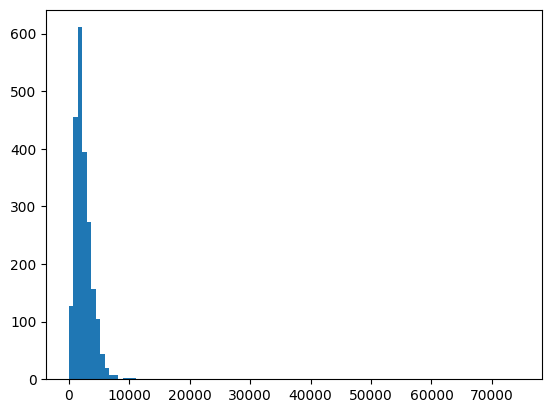

In [667]:
fig, ax = plt.subplots()

# ax.hist(recipe_calories[recipe_calories<40000], bins=100); 
ax.hist(recipe_calories, bins=100); 

In [668]:
burgers_arr_normalized = burgers_arr/recipe_calories[:, np.newaxis]*1000

One last thing: Combine patty and beef, and drop water as an ingredient

In [669]:
recipe_calories2 = np.zeros(len(burgers_arr))
for i in range(len(burgers_arr)):
    for j in range(len(unique_names)):
        ingr_name = unique_names[j]
        ingr_qnty = burgers_arr_normalized[i,j]
        if np.isnan(ingr_qnty):
            ingr_qnty = 0
        ingr_cal_per_gram = calorie_database[ingr_name]
        recipe_calories2[i] += ingr_qnty*ingr_cal_per_gram

In [670]:
i1 = np.where(unique_names=='beef')[0][0]
i2 = np.where(unique_names=='patty')[0][0]

combined = burgers_arr_normalized
combined[:,i1] += combined[:,i2]
combined = np.concatenate((combined[:,:i2], combined[:,i2+1:]), axis=1)
combined_names = np.concatenate((unique_names[:i2], unique_names[i2+1:]))

In [672]:
i = np.where(combined_names == 'water')[0][0]
combined = np.concatenate((combined[:,:i], combined[:,i+1:]), axis=1)
combined_names = np.concatenate((combined_names[:i], combined_names[i+1:]))

In [673]:
with open('data/burgers_step7.pkl', 'wb') as f:
    pickle.dump([combined, combined_names, calorie_database], f)

In [536]:
# with open('data/burgers_step7.pkl', 'rb') as f:
#     burgers_arr_normalized, unique_names, units, calorie_database, recipe_calories = pickle.load(f)

[]

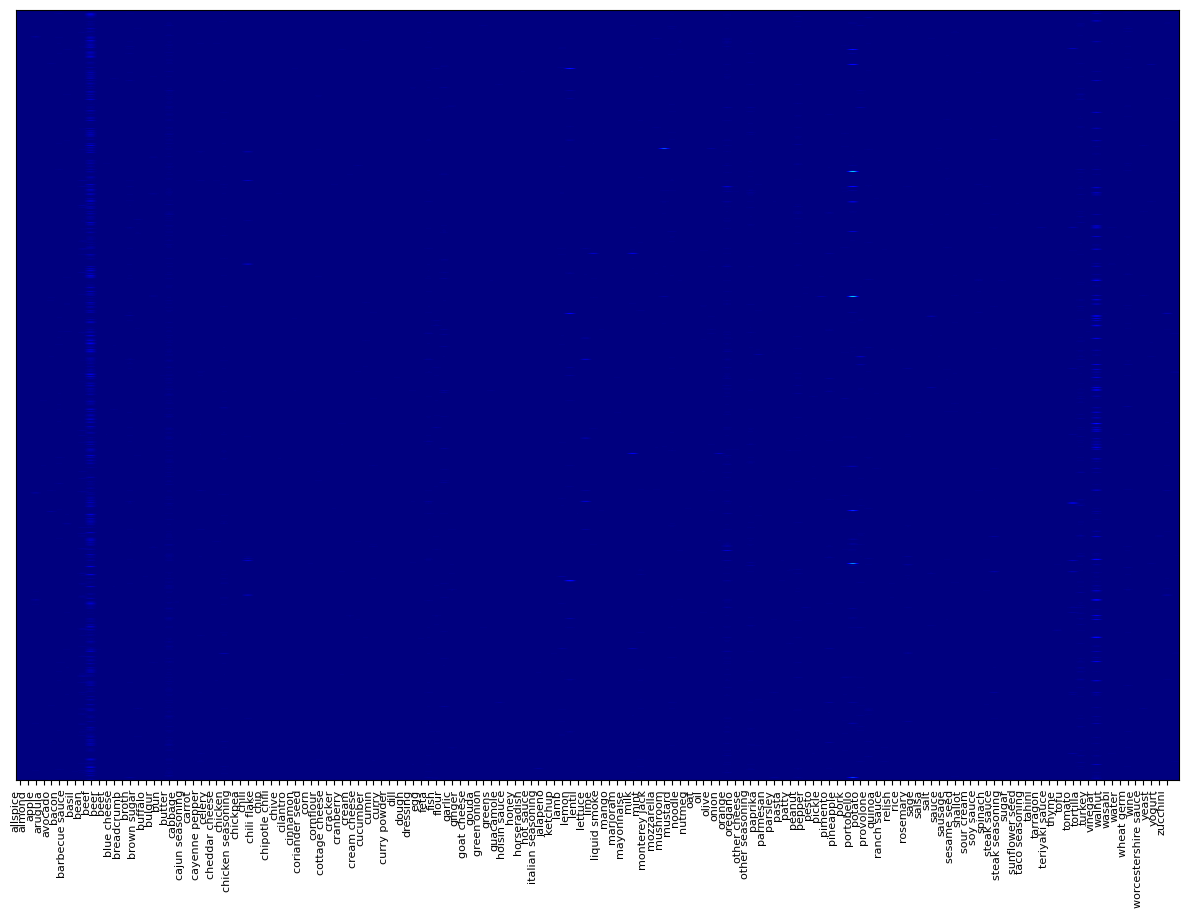

In [537]:
# burgers_nonan = np.nan_to_num(burgers_arr_normalized, nan=0.0)
# fig, ax = plt.subplots(figsize=(15,10))
# ax.imshow(burgers_nonan, cmap='jet', aspect='auto')

# ax.set_xticks(range(len(unique_names)))
# ax.set_xticklabels(unique_names, rotation=90, ha='right', fontsize=8); 

# ax.set_yticks([])